# Foundations of Machine learning

Problem Set 3

Emily Fu

In [ ]:
# importing packages

# train_test_split, GridSearchCV, KFold
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
# ridge regression, quantile regression, logistic regression
from sklearn.linear_model import Ridge, QuantileRegressor, LogisticRegression
# KNN
from sklearn.neighbors import KNeighborsClassifier
# standard scaler
from sklearn.preprocessing import StandardScaler
# pipeline
from sklearn.pipeline import Pipeline

import numpy as np

import matplotlib.pyplot as plt

# california housing dataset and wine dataset
from sklearn.datasets import fetch_california_housing, load_wine

In [ ]:
# import data and set parameters

# random seed
seed = 420

# number of folds for cross-validation
k_folds = 5

# define possible penalties in ridge regression
param_grid_ridge = {'ridge__alpha': np.logspace(-4, 4, 50)}

# define possible penalties in quantile regression 
# would have used the same as param_grid_ridge but it takes too long
param_grid_qr = {'qr__alpha': np.logspace(-4, 1, 10)}

# define the parameter grid (possible values for n_neighbors)
param_grid_knn = {'knn__n_neighbors': np.arange(1, 25)}

# penalty parameter grid for logistic regression
param_grid_logistic = {'logistic__C': np.logspace(-4, 4, 50)}

# Split the dataset into three parts: a training set (60%) used for initial model fitting, 
# a calibration set (20%) used for conformal inference calibration, 
# and a test set (20%) used for final evaluation.

# load data
housing = fetch_california_housing()
wine = load_wine()
X_housing, y_housing = housing['data'], housing['target']
X_wine, y_wine = wine['data'], wine['target']

# training vs test/calibration data
X_housing_train, X_housing_temp, y_housing_train, y_housing_temp = train_test_split(
    X_housing, y_housing, test_size=0.40, random_state=seed, shuffle=True)
X_wine_train, X_wine_temp, y_wine_train, y_wine_temp = train_test_split(
    X_wine, y_wine, test_size=0.40, random_state=seed, shuffle=True)

# calibration data and test data
X_housing_cal, X_housing_test, y_housing_cal, y_housing_test = train_test_split(
    X_housing_temp, y_housing_temp, test_size=0.50, random_state=seed, shuffle=True)
X_wine_cal, X_wine_test, y_wine_cal, y_wine_test = train_test_split(
    X_wine_temp, y_wine_temp, test_size=0.50, random_state=seed, shuffle=True)

# subset_indices of points for plotting
subset_indices = np.random.choice(len(X_housing_test), size=20, replace=False)

# store size of calibration set
n_housing_cal = len(X_housing_cal)
n_wine_cal = len(X_wine_cal)

# confidence interval
alpha = 0.1

# quantiles for quantile regression
quantile_05 = alpha / 2
quantile_95 = 1 - alpha / 2

# significance level
sig_housing = (1 - alpha) * (n_housing_cal + 1) / n_housing_cal
sig_wine = (1 - alpha) * (n_wine_cal + 1) / n_wine_cal

In [146]:
# function to implement conformal inference for the classification problem
def evaluate_conformal_classifier(best_model, X_cal, y_cal, X_test, 
                                  y_test, alpha=0.1, model_name='Model'):
    # classes and class-to-column mapping
    classes = best_model.classes_
    class_to_col = {c: j for j, c in enumerate(classes)}

    '''calculate conformity scores:
    For a fixed x, the classifier outputs a probability distribution over possible y
    sort labels by predicted probability
    small rank = very likely label
    large rank = unlikely label
    define s(x,y) as the total probability mass of other y’ that are at least as likely as y'''

    # calibration conformity scores
    # For a fixed x, the classifier outputs a probability distribution over possible y
    probs_cal = best_model.predict_proba(X_cal)
    # sort labels by highest probability
    order_cal = np.argsort(-probs_cal, axis=1)                   
    probs_sorted_cal = np.take_along_axis(probs_cal, order_cal, axis=1)
    # cumulative sums of sorted probabilities
    cumsum_sorted_cal = np.cumsum(probs_sorted_cal, axis=1)

    # column index of true class for each calibration point
    true_col_cal = np.array([class_to_col[y] for y in y_cal])

    # position of true class in the sorted probabilities
    pos_cal = np.array([
        np.where(order_cal[i] == true_col_cal[i])[0][0]
        for i in range(len(y_cal))])

    # conformity scores
    scores_cal = cumsum_sorted_cal[np.arange(len(y_cal)), pos_cal]

    # conformal quantile
    sig_wine = (1 - alpha) * (n_wine_cal + 1) / n_wine_cal
    
    #find the (1−alpha)(n+1)/n-th quantile of the calibration scores
    quantile = np.quantile(scores_cal, sig_wine)

    # test set conformity scores
    # For a fixed x, the classifier outputs a probability distribution over possible y
    probs_test = best_model.predict_proba(X_test)
    # sort labels by highest probability
    order_test = np.argsort(-probs_test, axis=1)
    probs_sorted_test = np.take_along_axis(probs_test, order_test, axis=1)
    # cumulative sums of sorted probabilities
    cumsum_sorted_test = np.cumsum(probs_sorted_test, axis=1)

    # prediction set in sorted coordinates
    mask_sorted = cumsum_sorted_test <= quantile

    # map mask back to original class order
    mask = np.zeros_like(mask_sorted, dtype=bool)
    for i in range(mask.shape[0]):
        mask[i, order_test[i]] = mask_sorted[i]

    # print stuff for evaluation

    # fraction of test points where the true label is in the prediction set
    true_col_test = np.array([class_to_col[y] for y in y_test])

    # empirical coverage and average set size
    empirical_coverage = np.mean(mask[np.arange(len(y_test)), true_col_test])
    avg_set_size = mask.sum(axis=1).mean()

    print(f'{model_name}:')
    print(f'Empirical coverage: {empirical_coverage:.3f}')
    print(f'Average set size: {avg_set_size:.3f}')

    print('Coverage rate by true class:')
    for c in classes:
        idx = (y_test == c)
        cov_c = np.mean(mask[idx, class_to_col[c]])
        print(f'  Class {c}: {cov_c:.3f}')

## Continuous Outcome Regression

Implement conformal inference for regression using ridge regression with penalty parameter selected via cross-validation as the model, and the conformity score: $s(X,y) = |y−\hat{f}(X)|$ where $\hat{f}(X)$ is the predicted value from the ridge regression model. 

Empirical coverage on the test set: 0.887
Average interval width: 2.090


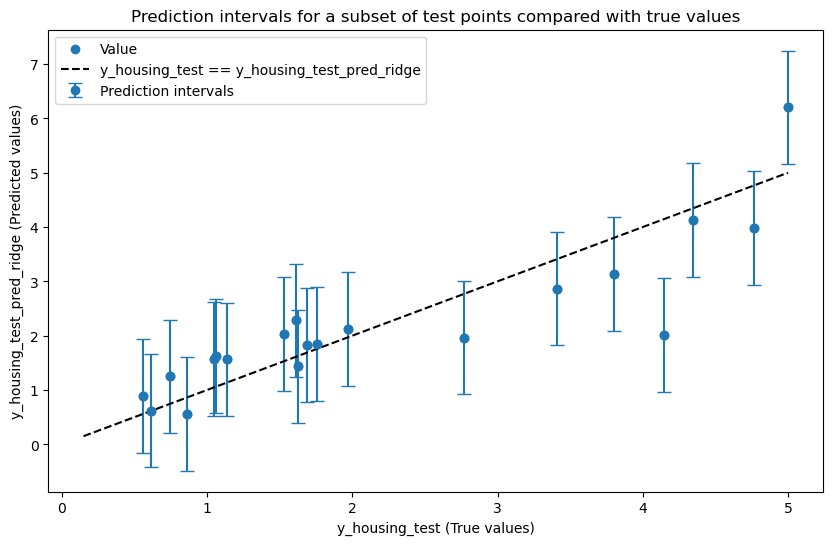

In [ ]:
# scaling features and ridge regression with grid search
# normalising data? apparently
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())])
# grid search with 5-fold cross-validation
grid_ridge = GridSearchCV(estimator=pipe_ridge, param_grid=param_grid_ridge, cv=k_folds)

# Train your penalized linear regression model on the training set using the optimal 
# penalty_housing found using cross-validation.
grid_ridge.fit(X_housing_train, y_housing_train)

# For each point (X_i,y_i) in the calibration set, compute the conformity_housing score s(X_i,y_i).
best_model_ridge = grid_ridge.best_estimator_
y_housing_cal_pred_ridge = best_model_ridge.predict(X_housing_cal)
conformity_housing_scores_ridge = np.abs(y_housing_cal - y_housing_cal_pred_ridge)

# For a desired confidence level 1−alpha (e.g., alpha = 0.1 for 90% confidence), 
# find the (1−alpha)(n+ 1)/n-th quantile of the calibration scores, 
# where n is the size of the calibration set.
quantile_ridge = np.quantile(conformity_housing_scores_ridge, sig_housing)

# For evaluation, construct prediction intervals [\hat{f}(X) - q, \hat{f}(X) + q] 
# where q is the appropriate quantile of calibration scores.
y_housing_test_pred_ridge = best_model_ridge.predict(X_housing_test)
lower_ridge = y_housing_test_pred_ridge - quantile_ridge
upper_ridge = y_housing_test_pred_ridge + quantile_ridge

# Compute empirical coverage on the test set, 
# when the true value falls within the prediction set
coverage_ridge = np.mean((y_housing_test >= lower_ridge) & (y_housing_test <= upper_ridge))
print(f'Empirical coverage on the test set: {coverage_ridge:.3f}')

# calculate average interval width, 
interval_widths_ridge = upper_ridge - lower_ridge
avg_interval_width_ridge = np.mean(interval_widths_ridge)
print(f'Average interval width: {avg_interval_width_ridge:.3f}')

# and plot prediction intervals for a subset of test points compared with true values.
plt.figure(figsize=(10, 6))
plt.scatter(y_housing_test[subset_indices], y_housing_test_pred_ridge[subset_indices], label='Value')
plt.errorbar(y_housing_test[subset_indices], y_housing_test_pred_ridge[subset_indices], 
             yerr=[y_housing_test_pred_ridge[subset_indices] - lower_ridge[subset_indices], 
                    upper_ridge[subset_indices] - y_housing_test_pred_ridge[subset_indices]], 
             fmt='o', capsize=5, label='Prediction intervals')
plt.plot([y_housing_test.min(), y_housing_test.max()], [y_housing_test.min(), y_housing_test.max()], 'k--', 
         label='y_housing_test == y_housing_test_pred_ridge')
plt.xlabel('y_housing_test (True values)')
plt.ylabel('y_housing_test_pred_ridge (Predicted values)')
plt.title('Prediction intervals for a subset of test points compared with true values')
plt.legend()
plt.show()

## Quantile Regression

Using the same continuous outcome dataset from the previous problem, implement conformal inference with quantile regression. Fit quantile regression models for quantiles $\tau_{\alpha/2}$ and $\tau_{1−\alpha/2}$ (e.g., 0.05 and 0.95 for $\alpha = 0.1$). Let $t_{\alpha/2}$ and $t_{1−\alpha/2}$ be the predicted quantiles. Use the conformity score: $s(X,y) = \text{max} [t_{\alpha/2}(X) − y, y − t_{1−\alpha/2}(X)]$

In [136]:
# create quantile regression models for the two quantiles
qr_05 = Pipeline([('scaler', StandardScaler()),
                  ('qr', QuantileRegressor(quantile=quantile_05))])
qr_95 = Pipeline([('scaler', StandardScaler()),
                  ('qr', QuantileRegressor(quantile=quantile_95))])

# grid search with 5-fold cross-validation for both quantiles
grid_qr_05 = GridSearchCV(estimator=qr_05, param_grid=param_grid_qr, cv=k_folds)
grid_qr_95 = GridSearchCV(estimator=qr_95, param_grid=param_grid_qr, cv=k_folds)

# fit the models on the training data
grid_qr_05.fit(X_housing_train, y_housing_train)
grid_qr_95.fit(X_housing_train, y_housing_train)

# For each point (Xi,yi) in the calibration set, compute the conformity score s(Xi,yi).
best_qr_05 = grid_qr_05.best_estimator_
best_qr_95 = grid_qr_95.best_estimator_
t_05_cal = grid_qr_05.predict(X_housing_cal)
t_95_cal = grid_qr_95.predict(X_housing_cal)
conformity_housing_scores_qr = np.maximum(t_05_cal - y_housing_cal, y_housing_cal - t_95_cal)

# For a desired confidence level 1−alpha (e.g., alpha = 0.1 for 90% confidence), 
# find the (1−alpha)(n+ 1)/n-th quantile of the calibration scores, where n is the size of the calibration set.
quantile_qr = np.quantile(conformity_housing_scores_qr, sig_housing)

# quantile regression confidence bands
t_05_test = grid_qr_05.predict(X_housing_test)
t_95_test = grid_qr_95.predict(X_housing_test)
lower_qr = t_05_test - quantile_qr
upper_qr = t_95_test + quantile_qr

# Compute empirical coverage on the test set, 
coverage_qr = np.mean((y_housing_test >= lower_qr) & (y_housing_test <= upper_qr))
print(f'Empirical coverage on the test set: {coverage_qr:.3f}')

# calculate average interval width, 
interval_widths_qr = upper_qr - lower_qr
avg_interval_width_qr = np.mean(interval_widths_qr)
print(f'Average interval width: {avg_interval_width_qr:.3f}')

Empirical coverage on the test set: 0.890
Average interval width: 2.208


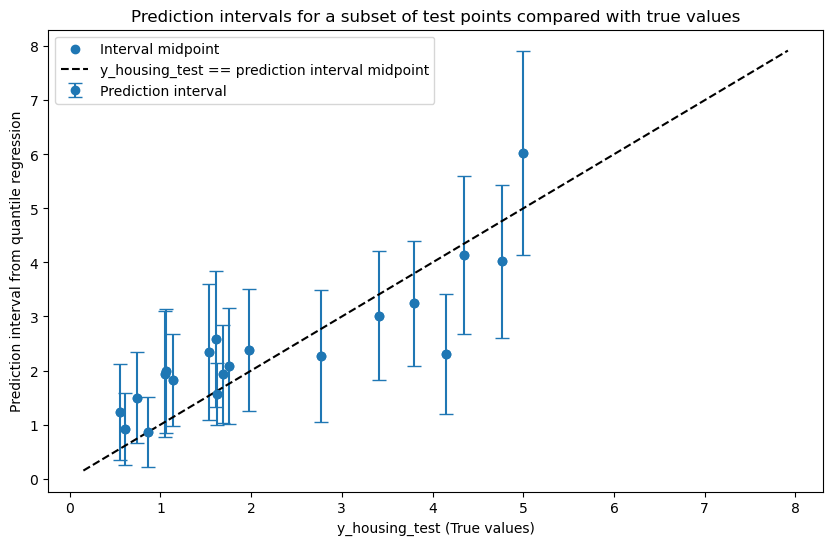

In [ ]:
# confidence bands for the same subset of test points
y_true_subset = y_housing_test[subset_indices]
lower_subset_qr = lower_qr[subset_indices]
upper_subset_qr = upper_qr[subset_indices]

# midpoint to plot against true values
center_subset_qr = (lower_subset_qr + upper_subset_qr) / 2

plt.figure(figsize=(10, 6))

# plot interval centers
plt.scatter(y_true_subset, center_subset_qr, label='Interval midpoint')

# plot prediction intervals
plt.errorbar(
    y_true_subset,
    center_subset_qr,
    yerr=[center_subset_qr - lower_subset_qr,
          upper_subset_qr - center_subset_qr],
    fmt='o',
    capsize=5,
    label='Prediction interval')

# 45-degree reference line
line_min = min(y_housing_test.min(), lower_subset_qr.min())
line_max = max(y_housing_test.max(), upper_subset_qr.max())
plt.plot([line_min, line_max], [line_min, line_max], 'k--', label='y_housing_test == prediction interval midpoint')

plt.xlabel('y_housing_test (True values)')
plt.ylabel('Prediction interval from quantile regression')
plt.title('Prediction intervals for a subset of test points compared with true values')
plt.legend()
plt.show()

Like we saw in the lectures, the point prediction score yields confidence bands of constant width and the quantile regression does not. I wasn't exactly sure how to plot the quantile regression results because I have two separate models for conditional quantiles, so I plotted the average point from the two (the interval is just shown around that point). The quantile regression confidence bands look like they get wider as the value of the target variable increases, which I think makes sense for our selection of target variable (median home price) because there's a lot more variation in home price at the upper end of the distribution. There are more extremely expensive homes than extremely cheap homes. The true test values are mostly within the confidence bands, which is because we set $\alpha = 0.1$ and we have the coverage theorem that states the probability that the test outcome is in the confidence band is at least $1 - \alpha = 0.9$. In the sample, the empirical coverage is rougly consistent with this guarantee

## Discrete Classification

Fit a penalized logistic regression model using scikit-learn’s LogisticRegression with L1 or L2 regularization. Use cross-validation on the training set to find the optimal penalty parameter λ that minimizes classification error.
ok to be honest i'm having the craziest case of food poisoning ever rn and this problemset is my final straw

Implement conformal inference for the classification problem using the following procedure. Let $j(y,x)$ be the rank of
f(y|x) across all possible labels y, where $\hat{f}(y|x)$ represents the predicted probability of class $y$ given features $x$. Define the conformity score as: $s(x,y) = \sum_{y'} 1(j(y|x) \geq j(y'|x))f(y|x)$, where $1(\cdot)$ is the indicator function

In [147]:
# logistic regression with penalty
pipe_logistic = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(penalty='l1', solver='liblinear'))])

# grid search with 5-fold cross-validation for logistic regression
grid_logistic = GridSearchCV(estimator=pipe_logistic, param_grid=param_grid_logistic, cv=k_folds)
grid_logistic.fit(X_wine_train, y_wine_train)
best_model_logistic = grid_logistic.best_estimator_

evaluate_conformal_classifier(
    best_model_logistic,
    X_wine_cal, y_wine_cal,
    X_wine_test, y_wine_test,
    alpha=alpha,
    model_name='Logistic Regression')

Logistic Regression:
Empirical coverage: 0.944
Average set size: 1.194
Coverage rate by true class:
  Class 0: 0.933
  Class 1: 1.000
  Class 2: 0.875


## k-Nearest Neighbors Classification

Repeat the conformal inference procedure from the previous problem, but replace the penalized logistic regression with k-nearest neighbors classification. Use cross-validation on the training set to select the optimal number of neighbors k. Use the same conformity score definition as in the previous problem. Compare the coverage and efficiency (average prediction set size) with the logistic regression results.

In [148]:
# knn classifier
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())])

# grid search with 5-fold cross-validation for knn
grid_knn = GridSearchCV(estimator=pipe_knn, param_grid=param_grid_knn, cv=k_folds)
grid_knn.fit(X_wine_train, y_wine_train)
best_model_knn = grid_knn.best_estimator_

evaluate_conformal_classifier(
    best_model_knn,
    X_wine_cal, y_wine_cal,
    X_wine_test, y_wine_test,
    alpha=alpha,
    model_name='KNN')

KNN:
Empirical coverage: 1.000
Average set size: 3.000
Coverage rate by true class:
  Class 0: 1.000
  Class 1: 1.000
  Class 2: 1.000
